In [14]:
# ============================================
# INSTALL & IMPORT
# ============================================

# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn tensorflow pytorch-tabnet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN

import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from pytorch_tabnet.tab_model import TabNetClassifier

import os
import pickle
import json
import time

print("✅ Library berhasil diimport")
print(f"TensorFlow version: {tf.__version__}")

✅ Library berhasil diimport
TensorFlow version: 2.21.0


In [15]:
# ============================================
# FOCAL LOSS FUNCTION
# ============================================

def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss untuk mengatasi class imbalance
    FL(p_t) = -α(1-p_t)^γ log(p_t)
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma) * y_true + (1 - alpha) * tf.pow(y_pred, gamma) * (1 - y_true)
        return tf.reduce_mean(weight * bce)
    return focal_loss_fixed

print("✅ Focal Loss function siap")

✅ Focal Loss function siap


In [16]:
# ============================================
# LOAD DATASET (FULL 15.000 DATA)
# ============================================

possible_paths = [
    '../data/HR_comma_sep.csv',
    'data/HR_comma_sep.csv',
    'HR_comma_sep.csv',
]

DATA_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    print("❌ Dataset tidak ditemukan!")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df.head()

✅ Dataset loaded: 14999 rows, 10 columns


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [17]:
# ============================================
# PREPROCESSING
# ============================================

print("=" * 60)
print("PREPROCESSING")
print("=" * 60)

target = 'left'
y = df[target].copy()
X = df.drop(columns=[target]).copy()

# Encoding kategorikal
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    print(f"   {col} encoded")

print(f"\nTotal fitur setelah encoding: {X.shape[1]}")

# Data splitting (80/10/10)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTraining Set   : {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation Set : {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Testing Set    : {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Standarisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Data telah distandarisasi")

PREPROCESSING
   sales encoded
   salary encoded

Total fitur setelah encoding: 9

Training Set   : 11999 samples (80.0%)
Validation Set : 1500 samples (10.0%)
Testing Set    : 1500 samples (10.0%)

✅ Data telah distandarisasi


In [18]:
# ============================================
# BUILD MODEL
# ============================================

def build_mlp_deep(input_dim, alpha_focal=0.25):
    """
    MLP Deep + Focal Loss
    Arsitektur: 4 Hidden Layers (256, 128, 64, 32)
    """
    inputs = Input(shape=(input_dim,))
    x = inputs
    
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Dense(32, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss=focal_loss(gamma=2.0, alpha=alpha_focal),
        metrics=['accuracy']
    )
    return model

def get_tabnet_params():
    return {
        'n_d': 64,
        'n_a': 64,
        'n_steps': 5,
        'gamma': 1.5,
        'lambda_sparse': 0.001,
        'mask_type': 'sparsemax',
        'verbose': 0
    }

print("✅ Build model siap")

✅ Build model siap


In [19]:
# ============================================
# HANDLING IMBALANCE - 3 SKENARIO
# ============================================

print("=" * 60)
print("HANDLING IMBALANCE - 3 SKENARIO")
print("=" * 60)

# SKENARIO 1: NO HANDLING
print("\n[1] NO HANDLING (Baseline)")
print(f"   Training: {len(y_train)} samples (IMBALANCED)")
print(f"   Keluar (1): {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")

# SKENARIO 2: SMOTE-ENN
print("\n[2] SMOTE-ENN")
smote_enn = SMOTEENN(random_state=42)
X_train_smote, y_train_smote = smote_enn.fit_resample(X_train_scaled, y_train)
print(f"   Sebelum: {len(y_train)} samples")
print(f"   Setelah: {len(X_train_smote)} samples")
print(f"   Keluar (1): {y_train_smote.sum()} ({y_train_smote.sum()/len(y_train_smote)*100:.2f}%)")

# SKENARIO 3: CLASS WEIGHT (untuk MLP) / Alpha Tuning (untuk Focal Loss)
class_weight = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weight))
print("\n[3] CLASS WEIGHT / ALPHA TUNING")
print(f"   Class Weight: {class_weight_dict}")
print(f"   Focal Loss Alpha akan di-tune (0.25, 0.5, 0.75)")
print(f"   Training: {len(y_train)} samples (TETAP IMBALANCED)")

HANDLING IMBALANCE - 3 SKENARIO

[1] NO HANDLING (Baseline)
   Training: 11999 samples (IMBALANCED)
   Keluar (1): 2857 (23.81%)

[2] SMOTE-ENN
   Sebelum: 11999 samples
   Setelah: 17391 samples
   Keluar (1): 8949 (51.46%)

[3] CLASS WEIGHT / ALPHA TUNING
   Class Weight: {np.int64(0): np.float64(0.6562568365784293), np.int64(1): np.float64(2.099929996499825)}
   Focal Loss Alpha akan di-tune (0.25, 0.5, 0.75)
   Training: 11999 samples (TETAP IMBALANCED)


In [20]:
# ============================================
# TRAINING MLP DEEP - 3 SKENARIO
# ============================================

print("=" * 60)
print("TRAINING MLP DEEP - 3 SKENARIO")
print("=" * 60)

input_dim = X_train_scaled.shape[1]
EPOCHS = 150
BATCH_SIZE = 32

mlp_results = {}
mlp_models = {}

# ---- SKENARIO 1: MLP + No Handling ----
print("\n[1] MLP Deep + No Handling")
model_mlp_nh = build_mlp_deep(input_dim, alpha_focal=0.25)
start = time.time()
history_mlp_nh = model_mlp_nh.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, monitor='val_loss'),
        EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss')
    ],
    verbose=1
)
time_mlp_nh = time.time() - start

y_pred = (model_mlp_nh.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
y_prob = model_mlp_nh.predict(X_test_scaled, verbose=0)
mlp_results['MLP_NoHandling'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_mlp_nh
}
mlp_models['MLP_NoHandling'] = model_mlp_nh

# ---- SKENARIO 2: MLP + SMOTE-ENN ----
print("\n[2] MLP Deep + SMOTE-ENN")
model_mlp_smote = build_mlp_deep(input_dim, alpha_focal=0.25)
start = time.time()
history_mlp_smote = model_mlp_smote.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, monitor='val_loss'),
        EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss')
    ],
    verbose=1
)
time_mlp_smote = time.time() - start

y_pred = (model_mlp_smote.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
y_prob = model_mlp_smote.predict(X_test_scaled, verbose=0)
mlp_results['MLP_SMOTE_ENN'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_mlp_smote
}
mlp_models['MLP_SMOTE_ENN'] = model_mlp_smote

# ---- SKENARIO 3: MLP + Class Weight (Alpha Tuning) ----
print("\n[3] MLP Deep + Class Weight (Alpha = 0.5)")
model_mlp_cw = build_mlp_deep(input_dim, alpha_focal=0.5)
start = time.time()
history_mlp_cw = model_mlp_cw.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[
        ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, monitor='val_loss'),
        EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss')
    ],
    verbose=1
)
time_mlp_cw = time.time() - start

y_pred = (model_mlp_cw.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
y_prob = model_mlp_cw.predict(X_test_scaled, verbose=0)
mlp_results['MLP_ClassWeight'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_mlp_cw
}
mlp_models['MLP_ClassWeight'] = model_mlp_cw

print("\n✅ MLP Training selesai!")

TRAINING MLP DEEP - 3 SKENARIO

[1] MLP Deep + No Handling
Epoch 1/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7677 - loss: 0.1107 - val_accuracy: 0.9427 - val_loss: 0.0305 - learning_rate: 5.0000e-04
Epoch 2/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8866 - loss: 0.0403 - val_accuracy: 0.9513 - val_loss: 0.0217 - learning_rate: 5.0000e-04
Epoch 3/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9026 - loss: 0.0299 - val_accuracy: 0.9573 - val_loss: 0.0178 - learning_rate: 5.0000e-04
Epoch 4/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9125 - loss: 0.0257 - val_accuracy: 0.9567 - val_loss: 0.0172 - learning_rate: 5.0000e-04
Epoch 5/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9222 - loss: 0.0227 - val_accuracy: 0.9567 - val_loss: 0.0163 - learning_rate: 5.0000e-04
Epoch 6/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9260 - loss: 0.0222 - val_accuracy: 0.9600 - val_loss: 0.0147 - learning_rate: 5.0000e-04

In [21]:
# ============================================
# TRAINING TABNET - 3 SKENARIO
# ============================================

print("=" * 60)
print("TRAINING TABNET - 3 SKENARIO")
print("=" * 60)

tabnet_results = {}
tabnet_models = {}
EPOCHS_TABNET = 100
BATCH_SIZE_TABNET = 512
VIRTUAL_BATCH_SIZE = 128

# ---- SKENARIO 1: TabNet + No Handling ----
print("\n[1] TabNet + No Handling")
tabnet_nh = TabNetClassifier(**get_tabnet_params())
start = time.time()
tabnet_nh.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=EPOCHS_TABNET,
    patience=EPOCHS_TABNET,
    batch_size=BATCH_SIZE_TABNET,
    virtual_batch_size=VIRTUAL_BATCH_SIZE,
    num_workers=0,
    drop_last=False
)
time_tabnet_nh = time.time() - start

y_pred = tabnet_nh.predict(X_test_scaled)
y_prob = tabnet_nh.predict_proba(X_test_scaled)[:, 1]
tabnet_results['TabNet_NoHandling'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_tabnet_nh
}
tabnet_models['TabNet_NoHandling'] = tabnet_nh

# ---- SKENARIO 2: TabNet + SMOTE-ENN ----
print("\n[2] TabNet + SMOTE-ENN")
tabnet_smote = TabNetClassifier(**get_tabnet_params())
start = time.time()
tabnet_smote.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_val_scaled, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=EPOCHS_TABNET,
    patience=EPOCHS_TABNET,
    batch_size=BATCH_SIZE_TABNET,
    virtual_batch_size=VIRTUAL_BATCH_SIZE,
    num_workers=0,
    drop_last=False
)
time_tabnet_smote = time.time() - start

y_pred = tabnet_smote.predict(X_test_scaled)
y_prob = tabnet_smote.predict_proba(X_test_scaled)[:, 1]
tabnet_results['TabNet_SMOTE_ENN'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_tabnet_smote
}
tabnet_models['TabNet_SMOTE_ENN'] = tabnet_smote

# ---- SKENARIO 3: TabNet + Class Weight (Duplikasi Fraud) ----
print("\n[3] TabNet + Class Weight (Duplikasi Fraud)")

# === PERBAIKIAN: GUNAKAN NUMPY ARRAY LANGSUNG ===
# Konversi y_train ke numpy array jika belum
if hasattr(y_train, 'values'):
    y_train_np = y_train.values
else:
    y_train_np = np.array(y_train)

# Cari indeks fraud di numpy array
fraud_indices = np.where(y_train_np == 1)[0]
fraud_X = X_train_scaled[fraud_indices]
fraud_y = y_train_np[fraud_indices]

print(f"   Fraud samples ditemukan: {len(fraud_indices)}")
print(f"   X_train_scaled shape: {X_train_scaled.shape}")
print(f"   fraud_X shape: {fraud_X.shape}")

# Duplikasi fraud 3x
X_train_weighted = np.vstack([X_train_scaled] + [fraud_X] * 2)
y_train_weighted = np.hstack([y_train_np] + [fraud_y] * 2)

print(f"   Original: {len(y_train)} samples")
print(f"   Weighted: {len(y_train_weighted)} samples")
print(f"   Keluar (1): {y_train_weighted.sum()} ({y_train_weighted.sum()/len(y_train_weighted)*100:.2f}%)")

tabnet_cw = TabNetClassifier(**get_tabnet_params())
start = time.time()
tabnet_cw.fit(
    X_train_weighted, y_train_weighted,
    eval_set=[(X_val_scaled, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=EPOCHS_TABNET,
    patience=EPOCHS_TABNET,
    batch_size=BATCH_SIZE_TABNET,
    virtual_batch_size=VIRTUAL_BATCH_SIZE,
    num_workers=0,
    drop_last=False
)
time_tabnet_cw = time.time() - start

y_pred = tabnet_cw.predict(X_test_scaled)
y_prob = tabnet_cw.predict_proba(X_test_scaled)[:, 1]
tabnet_results['TabNet_ClassWeight'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_tabnet_cw
}
tabnet_models['TabNet_ClassWeight'] = tabnet_cw

print("\n✅ TabNet Training selesai!")

TRAINING TABNET - 3 SKENARIO

[1] TabNet + No Handling
Stop training because you reached max_epochs = 100 with best_epoch = 56 and best_val_auc = 0.9875

[2] TabNet + SMOTE-ENN
Stop training because you reached max_epochs = 100 with best_epoch = 91 and best_val_auc = 0.98604

[3] TabNet + Class Weight (Duplikasi Fraud)
   Fraud samples ditemukan: 2857
   X_train_scaled shape: (11999, 9)
   fraud_X shape: (2857, 9)
   Original: 11999 samples
   Weighted: 17713 samples
   Keluar (1): 8571 (48.39%)
Stop training because you reached max_epochs = 100 with best_epoch = 93 and best_val_auc = 0.98825

✅ TabNet Training selesai!


In [22]:
# ============================================
# PERBANDINGAN 6 KOMBINASI
# ============================================

print("=" * 60)
print("PERBANDINGAN 6 KOMBINASI")
print("=" * 60)

all_results = {**mlp_results, **tabnet_results}

comparison_df = pd.DataFrame({
    'Kombinasi': list(all_results.keys()),
    'Model': [k.split('_')[0] for k in all_results.keys()],
    'Imbalance': [k.split('_')[1] if len(k.split('_')) > 1 else 'Unknown' for k in all_results.keys()],
    'Accuracy': [r['accuracy'] for r in all_results.values()],
    'Precision': [r['precision'] for r in all_results.values()],
    'Recall': [r['recall'] for r in all_results.values()],
    'F1-Score': [r['f1'] for r in all_results.values()],
    'AUC-ROC': [r['auc'] for r in all_results.values()],
    'Training Time (s)': [r['training_time'] for r in all_results.values()]
})

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
display(comparison_df)

# Simpan
ROOT_DIR = os.path.dirname(os.getcwd())
MODELS_DIR = os.path.join(ROOT_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

comparison_df.to_csv(os.path.join(MODELS_DIR, 'comparison_results.csv'), index=False)
print(f"\n✅ Hasil perbandingan disimpan: {os.path.join(MODELS_DIR, 'comparison_results.csv')}")

PERBANDINGAN 6 KOMBINASI


,Kombinasi,Model,Imbalance,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Training Time (s)
0,MLP_NoHandling,MLP,NoHandling,0.974000,0.973214,0.915966,0.943723,0.990678,141.647700
2,MLP_ClassWeight,MLP,ClassWeight,0.973333,0.964809,0.921569,0.942693,0.989798,77.705828
3,TabNet_NoHandling,TabNet,NoHandling,0.970000,0.958824,0.913165,0.935438,0.987676,196.093280
1,MLP_SMOTE_ENN,MLP,SMOTE,0.968000,0.945245,0.918768,0.931818,0.980995,54.430694
4,TabNet_SMOTE_ENN,TabNet,SMOTE,0.960667,0.904891,0.932773,0.918621,0.985095,282.371801
5,TabNet_ClassWeight,TabNet,ClassWeight,0.959333,0.895722,0.938375,0.916553,0.982676,279.120959



✅ Hasil perbandingan disimpan: d:\Projects\hr-analytics-deeplearning\models\comparison_results.csv


✅ Plot perbandingan disimpan: d:\Projects\hr-analytics-deeplearning\models\comparison_plot.png


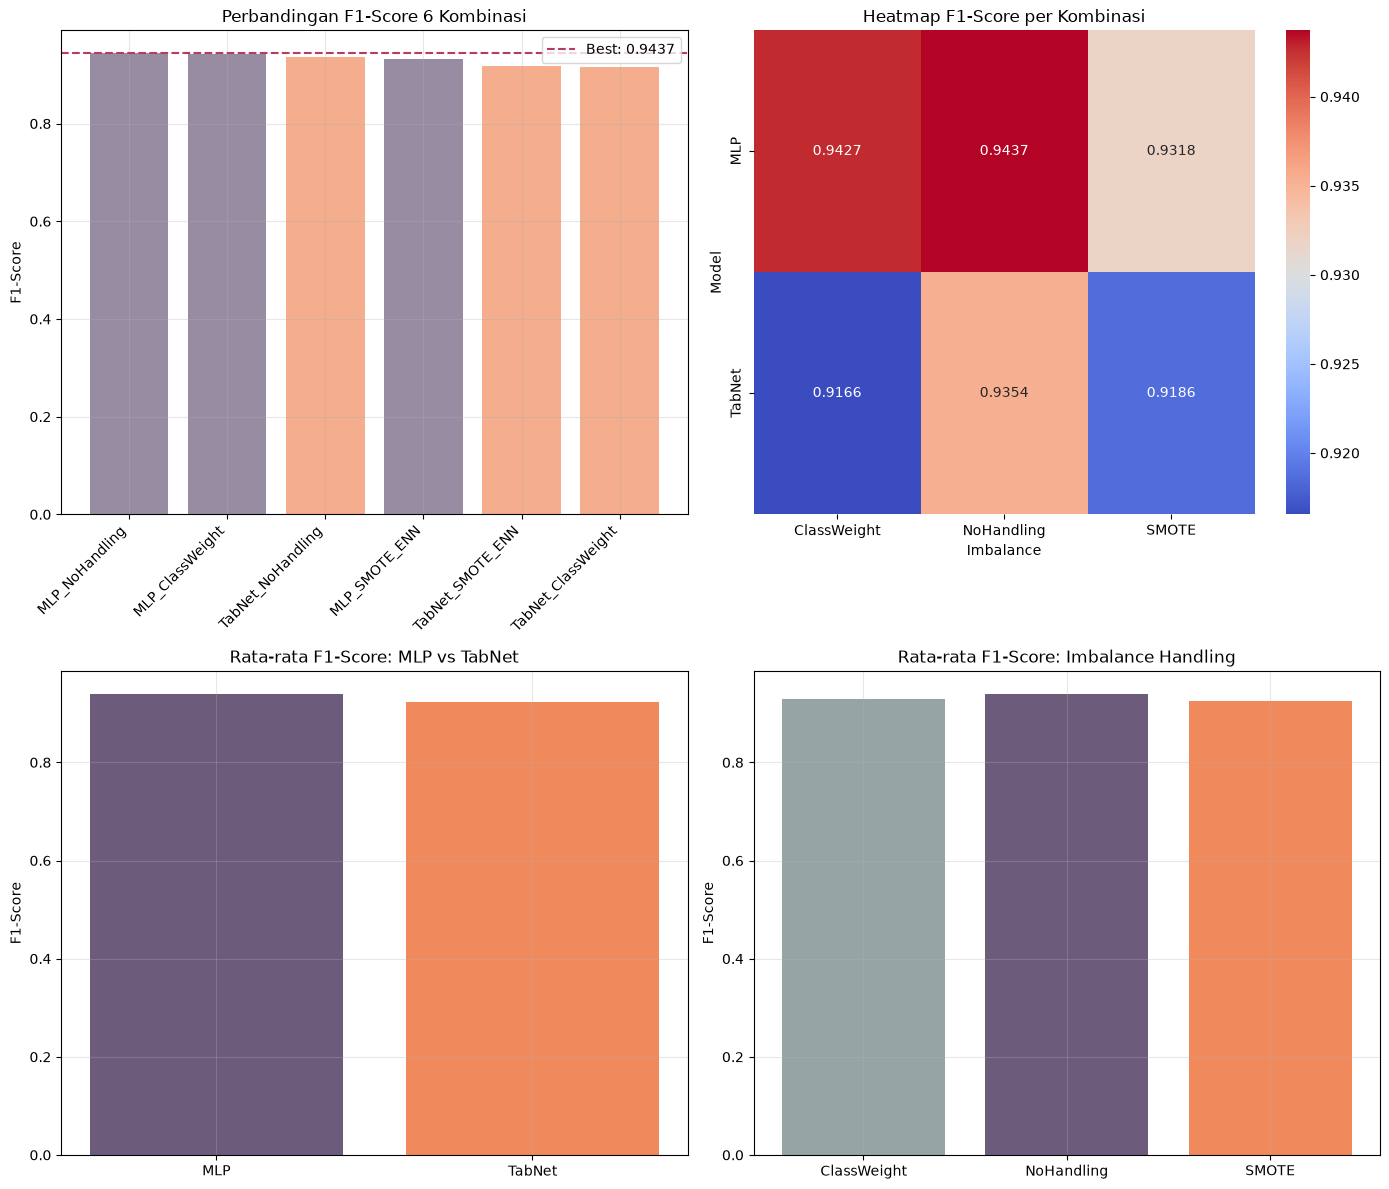

In [23]:
# ============================================
# VISUALISASI PERBANDINGAN
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Bar Chart F1-Score
colors = ['#6c5b7b' if 'MLP' in k else '#f08a5d' for k in comparison_df['Kombinasi']]
axes[0, 0].bar(comparison_df['Kombinasi'], comparison_df['F1-Score'], color=colors, alpha=0.7)
axes[0, 0].set_xticklabels(comparison_df['Kombinasi'], rotation=45, ha='right')
axes[0, 0].set_ylabel('F1-Score')
axes[0, 0].set_title('Perbandingan F1-Score 6 Kombinasi')
axes[0, 0].axhline(y=comparison_df['F1-Score'].max(), color='#b83b5e', linestyle='--', 
                label=f"Best: {comparison_df['F1-Score'].max():.4f}")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Heatmap
pivot = comparison_df.pivot_table(index='Model', columns='Imbalance', values='F1-Score')
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Heatmap F1-Score per Kombinasi')

# 3. Perbandingan Model
model_comp = comparison_df.groupby('Model').agg({'F1-Score': 'mean'}).reset_index()
axes[1, 0].bar(model_comp['Model'], model_comp['F1-Score'], color=['#6c5b7b', '#f08a5d'])
axes[1, 0].set_title('Rata-rata F1-Score: MLP vs TabNet')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].grid(True, alpha=0.3)

# 4. Perbandingan Imbalance Handling
imbalance_comp = comparison_df.groupby('Imbalance').agg({'F1-Score': 'mean'}).reset_index()
axes[1, 1].bar(imbalance_comp['Imbalance'], imbalance_comp['F1-Score'], 
               color=['#95a5a6', '#6c5b7b', '#f08a5d'])
axes[1, 1].set_title('Rata-rata F1-Score: Imbalance Handling')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'comparison_plot.png'), dpi=150)
print(f"✅ Plot perbandingan disimpan: {os.path.join(MODELS_DIR, 'comparison_plot.png')}")
plt.show()

In [24]:
# ============================================
# FIND OPTIMAL THRESHOLD (UNTUK BEST MODEL)
# ============================================

print("=" * 60)
print("FIND OPTIMAL THRESHOLD")
print("=" * 60)

best_key = comparison_df.iloc[0]['Kombinasi']
best_model = None

# Pilih model terbaik
if best_key in mlp_models:
    best_model = mlp_models[best_key]
    model_type = 'mlp'
else:
    best_model = tabnet_models[best_key]
    model_type = 'tabnet'

print(f"Best model: {best_key} ({model_type})")

# Prediksi probabilitas di validation set
if model_type == 'mlp':
    y_val_prob = best_model.predict(X_val_scaled, verbose=0).flatten()
else:
    y_val_prob = best_model.predict_proba(X_val_scaled)[:, 1]

# Cari threshold optimal
thresholds = np.arange(0.1, 0.6, 0.05)
best_f1 = 0
best_threshold = 0.5

print(f"\n📊 Threshold Tuning:")
print(f"   Threshold | Precision | Recall | F1-Score")
print(f"   {'-'*45}")

for thresh in thresholds:
    y_pred = (y_val_prob >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    
    print(f"   {thresh:.2f}     | {prec:.4f}    | {rec:.4f} | {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\n✅ Best threshold: {best_threshold:.2f} (F1: {best_f1:.4f})")

FIND OPTIMAL THRESHOLD
Best model: MLP_NoHandling (mlp)

📊 Threshold Tuning:
   Threshold | Precision | Recall | F1-Score
   ---------------------------------------------
   0.10     | 0.5769    | 0.9776 | 0.7256
   0.15     | 0.7196    | 0.9776 | 0.8290
   0.20     | 0.8131    | 0.9748 | 0.8866
   0.25     | 0.8982    | 0.9636 | 0.9297
   0.30     | 0.9297    | 0.9636 | 0.9464
   0.35     | 0.9501    | 0.9608 | 0.9554
   0.40     | 0.9712    | 0.9440 | 0.9574
   0.45     | 0.9738    | 0.9356 | 0.9543
   0.50     | 0.9763    | 0.9216 | 0.9481
   0.55     | 0.9820    | 0.9188 | 0.9493

✅ Best threshold: 0.40 (F1: 0.9574)


In [25]:
# ============================================
# SIMPAN MODEL & PREPROCESSING
# ============================================

print("=" * 60)
print("MENYIMPAN MODEL & PREPROCESSING")
print("=" * 60)

# 1. Simpan best model
if model_type == 'mlp':
    best_model.save(os.path.join(MODELS_DIR, 'best_model.h5'))
    print(f"✅ best_model.h5 saved (MLP)")
else:
    best_model.save_model(os.path.join(MODELS_DIR, 'best_model.zip'))
    print(f"✅ best_model.zip saved (TabNet)")

# 2. Simpan scaler
with open(os.path.join(MODELS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ scaler.pkl saved")

# 3. Simpan encoders
with open(os.path.join(MODELS_DIR, 'encoders.pkl'), 'wb') as f:
    pickle.dump(encoders, f)
print(f"✅ encoders.pkl saved")

# 4. Simpan feature info
best_f1_score = comparison_df.iloc[0]['F1-Score']
best_acc = comparison_df.iloc[0]['Accuracy']
best_recall = comparison_df.iloc[0]['Recall']
best_precision = comparison_df.iloc[0]['Precision']

feature_info = {
    'feature_cols': X.columns.tolist(),
    'target_col': target,
    'best_model': best_key,
    'f1_score': float(best_f1_score),
    'accuracy': float(best_acc),
    'recall': float(best_recall),
    'precision': float(best_precision),
    'optimal_threshold': float(best_threshold),
    'input_dim': X_train.shape[1],
    'dataset_size': len(df),
    'model_type': model_type
}

with open(os.path.join(MODELS_DIR, 'feature_info.json'), 'w') as f:
    json.dump(feature_info, f, indent=2)
print(f"✅ feature_info.json saved (with optimal_threshold)")

print("\n" + "=" * 60)
print("✅ SEMUA FILE TERSIMPAN!")
print("=" * 60)

MENYIMPAN MODEL & PREPROCESSING
✅ best_model.h5 saved (MLP)
✅ scaler.pkl saved
✅ encoders.pkl saved
✅ feature_info.json saved (with optimal_threshold)

✅ SEMUA FILE TERSIMPAN!


In [26]:
# ============================================
# RINGKASAN FINAL
# ============================================

print("=" * 60)
print("✅ TRAINING SELESAI!")
print("=" * 60)

print(f"""
RINGKASAN:
------------------------------------------------------------
Dataset         : {df.shape[0]} rows, {df.shape[1]} columns
Target          : {target}
Imbalance       : {y.sum()/len(y)*100:.2f}% Keluar

Data Split      : Train 80%, Val 10%, Test 10%

2 METODE × 3 SKENARIO = 6 KOMBINASI:
------------------------------------------------------------
1. MLP Deep + Focal Loss
   - No Handling
   - SMOTE-ENN
   - Class Weight (Alpha=0.5)

2. TabNet
   - No Handling
   - SMOTE-ENN
   - Class Weight (Duplikasi Fraud)

HASIL PERBANDINGAN:
------------------------------------------------------------
""")

for i, row in comparison_df.iterrows():
    print(f"{row['Kombinasi']:<25} F1: {row['F1-Score']:.4f}  Acc: {row['Accuracy']:.4f}  Time: {row['Training Time (s)']:.1f}s")

print(f"""
------------------------------------------------------------
🏆 MODEL TERBAIK: {best_key}
   F1-Score: {best_f1_score:.4f}
   Accuracy: {best_acc:.4f}
   Recall: {best_recall:.4f}
   Precision: {best_precision:.4f}
   Optimal Threshold: {best_threshold:.2f}

File tersimpan di folder '{MODELS_DIR}/':
   - best_model.h5 (atau best_model.zip)
   - scaler.pkl
   - encoders.pkl
   - feature_info.json (dengan optimal_threshold)
   - comparison_results.csv
   - comparison_plot.png

SELANJUTNYA:
   Jalankan GUI:
   cd ..
   uvicorn app.main:app --reload --host 0.0.0.0 --port 8000
------------------------------------------------------------
""")

✅ TRAINING SELESAI!

RINGKASAN:
------------------------------------------------------------
Dataset         : 14999 rows, 10 columns
Target          : left
Imbalance       : 23.81% Keluar

Data Split      : Train 80%, Val 10%, Test 10%

2 METODE × 3 SKENARIO = 6 KOMBINASI:
------------------------------------------------------------
1. MLP Deep + Focal Loss
   - No Handling
   - SMOTE-ENN
   - Class Weight (Alpha=0.5)

2. TabNet
   - No Handling
   - SMOTE-ENN
   - Class Weight (Duplikasi Fraud)

HASIL PERBANDINGAN:
------------------------------------------------------------

MLP_NoHandling            F1: 0.9437  Acc: 0.9740  Time: 141.6s
MLP_ClassWeight           F1: 0.9427  Acc: 0.9733  Time: 77.7s
TabNet_NoHandling         F1: 0.9354  Acc: 0.9700  Time: 196.1s
MLP_SMOTE_ENN             F1: 0.9318  Acc: 0.9680  Time: 54.4s
TabNet_SMOTE_ENN          F1: 0.9186  Acc: 0.9607  Time: 282.4s
TabNet_ClassWeight        F1: 0.9166  Acc: 0.9593  Time: 279.1s

--------------------------------